# Inspect RF features — sanity checks & engineered-feature sandbox

Companion to [rf_gapfill.py](rf_gapfill.py) and [features.py](features.py).

Two cheap paths:
1. **Single-slot grid** — `build_feature_grid(slot_utc)` for one timestamp. Fastest way to eyeball a new feature's value range on a (NLAT, NLON) grid.
2. **Small training table** — call `build_training_table` over a short window with a tiny `target_rows`. This is the distribution the RF actually *trains* on (post-stratification), which is what `df['fire_frp_log_24h'].describe()` should reflect.

Use Section 4 to scaffold a new engineered feature.

## 0 - Setup

In [1]:
from __future__ import annotations
import os, sys
from datetime import date, datetime
from pathlib import Path

os.environ.setdefault('HDF5_USE_FILE_LOCKING', 'FALSE')
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import config as cfg
import ancillary as anc
from features import build_feature_grid, stack_features, build_training_table
from slots    import iter_local_days, iter_window_slots

pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print('RF_FEATURES:', cfg.RF_FEATURES)

/home/work1/miniconda3/envs/Airqua_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


RF_FEATURES: ['cams_aod', 'cams_aod_lag_3h', 't2m', 'dpt', 'rh', 'sp', 'u10', 'v10', 'blh', 'tcc', 'tcwv', 'ssrd', 'fal', 'precip_6h', 'precip_24h', 'hours_since_rain_0p1mm', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'fire_frp_log_24h', 'elevation', 'land_cover', 'population', 'region_idx', 'ndvi']


## 1 - Single-slot grid (fast)

Pick a slot inside the training window and inspect every feature's per-cell statistics on the (NLAT, NLON) grid. No sampling, no I/O loop — one CAMS read, one ERA5 read, one IMERG window.

In [2]:
# Pick the first window slot of the first training day that actually has
# Stage A coverage. iter_window_slots(day) is empty when discover_day_window
# returns None — common at the very edge of the training window.
probe_slot = None
for probe_day in iter_local_days(cfg.TRAIN_START, cfg.TRAIN_END):
    probe_slot = next(iter_window_slots(probe_day), None)
    if probe_slot is not None:
        break
if probe_slot is None:
    raise RuntimeError(
        f'No Stage A slots discoverable in [{cfg.TRAIN_START}, {cfg.TRAIN_END}].'
    )
print('probe day  (local):', probe_day.isoformat())
print('probe slot (UTC)  :', probe_slot.isoformat())

grids = build_feature_grid(probe_slot)

grid_stats = pd.DataFrame({
    name: pd.Series(g.ravel()).describe()
    for name, g in grids.items() if name in cfg.RF_FEATURES
}).T
grid_stats

probe day  (local): 2022-09-01
probe slot (UTC)  : 2022-09-01T02:00:00


,count,mean,std,min,25%,50%,75%,max
cams_aod,49600.0000,0.2127,0.1476,0.0298,0.1038,0.1809,0.2676,0.8273
cams_aod_lag_3h,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
t2m,49600.0000,28.0188,2.0332,18.0209,27.3368,28.3950,29.3727,32.9762
dpt,49600.0000,24.0495,1.4784,16.2482,23.7058,24.4673,24.9295,27.0961
rh,49600.0000,79.3700,6.2234,47.2598,75.7372,79.1693,82.7935,97.6423
sp,49600.0000,982.6218,36.4690,823.7168,972.1129,996.7744,1009.4319,1012.2933
u10,49600.0000,0.1157,1.1463,-4.2401,-0.4415,0.1876,0.7031,3.5853
v10,49600.0000,-0.5509,1.5473,-7.4964,-0.9670,-0.3976,0.1561,3.2457
blh,49600.0000,488.5527,126.3917,89.9504,411.6907,492.5279,571.2589,1051.0717
tcc,49600.0000,49.8758,32.2357,0.0000,20.9382,43.3955,80.5248,100.0000


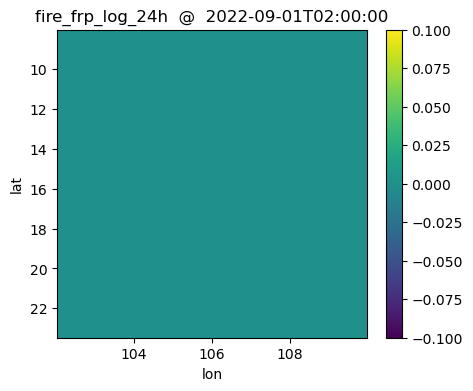

In [3]:
# Eyeball one feature as a map — defaults to fire_frp_log_24h.
FEATURE_TO_PLOT = 'fire_frp_log_24h'

g = grids[FEATURE_TO_PLOT]
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(g, origin='lower',
               extent=(cfg.LONS[0], cfg.LONS[-1], cfg.LATS[0], cfg.LATS[-1]),
               aspect='auto')
ax.set_title(f'{FEATURE_TO_PLOT}  @  {probe_slot.isoformat()}')
ax.set_xlabel('lon'); ax.set_ylabel('lat')
plt.colorbar(im, ax=ax); plt.show()

## 2 - Small training-table sample

Uses a *short* window and a tiny `target_rows` so this is minutes, not hours. The returned X is the matrix the RF sees post-stratification.

In [4]:
# Quick sample — keep date range and target_rows small for an interactive run.
SAMPLE_START = cfg.TRAIN_START
SAMPLE_END   = cfg.TRAIN_START  # one day; widen if you have time.
TARGET_ROWS  = 20_000           # vs. cfg.RF_TRAIN_TARGET_ROWS in production.

X, y, meta = build_training_table(
    start=SAMPLE_START, end=SAMPLE_END,
    target_rows=TARGET_ROWS, progress=tqdm,
)
df = pd.concat([X, y.rename('aod_slot'), meta], axis=1)
print(f'rows: {len(df):,}   features: {len(X.columns)}')
df.head()

build features: 100%|██████████| 10/10 [00:00<00:00, 25.03it/s]

  build_training_table audit:
    n_rows                = 14,582
    mean(y_train)         = +0.18326
    mean(y_train - cams)  = +0.01120  (unconditional residual prior — target ≈ 0)
    decile share          = d0:0.098 d1:0.120 d2:0.125 d3:0.111 d4:0.098 d5:0.095 d6:0.090 d7:0.087 d8:0.089 d9:0.086
    decile share natural  ≈ 0.100 each (by decile-edge construction)
rows: 14,582   features: 26


,cams_aod,cams_aod_lag_3h,t2m,dpt,rh,sp,u10,v10,blh,tcc,...,land_cover,population,region_idx,ndvi,aod_slot,date,slot_idx,row,col,aod_decile
0,0.0895,NaN,28.7044,23.9903,75.7276,1009.8164,1.4755,1.5026,437.4692,4.7379,...,17.0000,0.0000,1.0000,0.0000,0.1214,2022-09-01,4,205,152,2
1,0.0895,NaN,28.6518,24.0894,76.4089,1009.3536,1.5264,1.6188,442.9742,4.0677,...,17.0000,0.0000,1.0000,0.0000,0.1234,2022-09-01,4,205,153,2
2,0.0895,NaN,28.5993,24.1885,77.0901,1008.8907,1.5774,1.7351,448.4792,3.3975,...,17.0000,0.0000,1.0000,0.0000,0.1272,2022-09-01,4,205,154,2
3,0.0895,NaN,28.5830,24.2875,77.6172,1008.6895,1.5819,1.8494,458.2579,2.7562,...,17.0000,0.0000,1.0000,0.0000,0.1345,2022-09-01,4,205,155,2
4,0.0905,NaN,28.6792,23.9881,75.8256,1009.4004,1.4341,1.4279,440.4942,3.6850,...,17.0000,0.0000,1.0000,0.0000,0.1075,2022-09-01,4,206,152,2


## 3 - The thing you asked for

In [5]:
df['fire_frp_log_24h'].describe()

count   14582.0000
mean        0.0304
std         0.3136
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0000
max         4.7300
Name: fire_frp_log_24h, dtype: float64

fire_frp_log_24h: zero=0.990  nonzero=0.010  nan=0.000


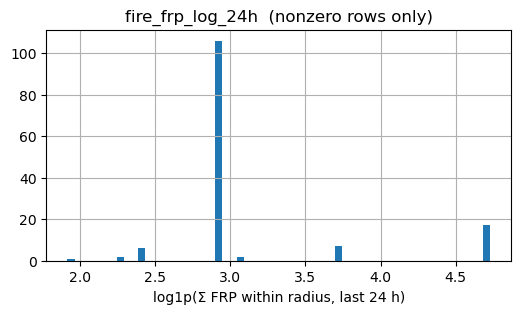

In [10]:
# Zero-share is informative: log1p(0) == 0 for cells without a nearby fire.
zero_frac = float((df['fire_frp_log_24h'] == 0).mean())
nonzero_frac = float((df['fire_frp_log_24h'] > 0).mean())
nan_frac  = float(df['fire_frp_log_24h'].isna().mean())
print(f'fire_frp_log_24h: zero={zero_frac:.3f}  nonzero={nonzero_frac:.3f}  nan={nan_frac:.3f}')

fig, ax = plt.subplots(figsize=(6, 3))
df.loc[df['fire_frp_log_24h'] > 0, 'fire_frp_log_24h'].hist(bins=60, ax=ax)
ax.set_title('fire_frp_log_24h  (nonzero rows only)')
ax.set_xlabel('log1p(Σ FRP within radius, last 24 h)')
plt.show()

In [7]:
# Per-feature describe across the sampled training rows.
X.describe().T

,count,mean,std,min,25%,50%,75%,max
cams_aod,14582.0000,0.1721,0.0861,0.0305,0.1071,0.1666,0.2225,0.6082
cams_aod_lag_3h,14446.0000,0.1647,0.0844,0.0301,0.1026,0.1577,0.2129,0.7686
t2m,14582.0000,30.4020,1.8725,20.9792,28.9613,30.4460,31.6769,34.9319
dpt,14582.0000,24.2308,1.1337,17.0800,23.8414,24.4650,24.8996,27.0233
rh,14582.0000,70.1160,7.3639,49.1817,64.4823,69.7716,76.2581,92.2073
sp,14582.0000,991.7039,24.6892,845.4390,986.2283,1000.3804,1007.7622,1011.3668
u10,14582.0000,0.5791,1.2310,-4.9691,0.0826,0.6242,1.1645,3.8095
v10,14582.0000,-0.2777,1.3723,-6.7032,-0.8555,-0.3680,0.5737,4.5043
blh,14582.0000,858.9369,261.1956,159.8889,613.2778,868.2654,1061.6198,1539.3752
tcc,14582.0000,32.5815,21.5404,0.0000,15.5515,28.0242,45.5913,100.0000


## 4 - Sandbox: try a new engineered feature

Build the candidate feature **outside** of `features.py` first so you can iterate without touching the production builder. Once it looks sane, lift it into `build_feature_grid` and add the name to `cfg.RF_FEATURES_DYNAMIC` / `_STATIC` / `_QUASISTATIC`.

In [8]:
# TODO: define a candidate engineered feature on the per-slot grid.
#
# Contract:
#   build_candidate(grids: dict[str, np.ndarray], slot_utc: datetime) -> np.ndarray
#   - shape  : (cfg.NLAT, cfg.NLON)
#   - dtype  : float32
#   - NaN policy: NaN is OK (RF imputes via median); but constants/zeros
#     are usually a better default for proxies where 'absent' has meaning
#     (compare fire_frp_log_24h, which uses 0.0 not NaN).
#
# Some directions to consider (pick one — keep the implementation tight):
#   - 'wind_speed'         = sqrt(u10**2 + v10**2)
#   - 'wind_dir_sin/cos'   = sin/cos(atan2(v10, u10))   (cyclical encoding)
#   - 'tcwv_x_blh'         = tcwv * blh   (moisture-loaded boundary layer proxy)
#   - 'cams_minus_lag'     = cams_aod - cams_aod_lag_3h  (transport tendency)
#   - 'dry_spell_x_ssrd'   = hours_since_rain_0p1mm * ssrd  (photo-oxidation aging proxy)
#
# Trade-offs to weigh:
#   - Interaction terms (products) help linear-ish models; RF can often discover
#     them on its own but a shallow forest may not. Worth testing.
#   - Cyclical encodings only help when the raw direction wraps (wind, hour).
#   - Lag differences add a new noise floor — check the SD against the source
#     features' SDs before trusting it as signal.

CANDIDATE_NAME = 'TODO_new_feature'

def build_candidate(grids: dict, slot_utc: datetime) -> np.ndarray:
    # TODO: implement and return a (NLAT, NLON) float32 grid.
    raise NotImplementedError(
        'Define build_candidate(grids, slot_utc) — see TODO above.'
    )

# Probe on the single slot from Section 1.
cand_grid = build_candidate(grids, probe_slot)
assert cand_grid.shape == (cfg.NLAT, cfg.NLON), cand_grid.shape
assert cand_grid.dtype == np.float32, cand_grid.dtype

pd.Series(cand_grid.ravel()).describe()

NotImplementedError: Define build_candidate(grids, slot_utc) — see TODO above.

In [ ]:
# Map view of the candidate.
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cand_grid, origin='lower',
               extent=(cfg.LONS[0], cfg.LONS[-1], cfg.LATS[0], cfg.LATS[-1]),
               aspect='auto')
ax.set_title(f'{CANDIDATE_NAME}  @  {probe_slot.isoformat()}')
ax.set_xlabel('lon'); ax.set_ylabel('lat')
plt.colorbar(im, ax=ax); plt.show()

In [ ]:
# Correlation of the candidate against the existing feature set, evaluated on
# the sampled training rows. The cheap proxy uses (row, col) from `meta` to
# look up the candidate value on each slot's grid — only practical when the
# sample window is short (we rebuild the grid for every distinct slot).
candidate_vals = np.empty(len(df), dtype=np.float32)
for (d, s_idx), g in df.groupby(['date', 'slot_idx']).groups.items():
    slot_utc = datetime(d.year, d.month, d.day, s_idx // 2, (s_idx % 2) * 30)
    g_grids  = build_feature_grid(slot_utc)
    c_grid   = build_candidate(g_grids, slot_utc)
    rows = df.loc[g, 'row'].to_numpy()
    cols = df.loc[g, 'col'].to_numpy()
    candidate_vals[g] = c_grid[rows, cols]

df_cand = X.copy()
df_cand[CANDIDATE_NAME] = candidate_vals
df_cand['aod_slot']     = y.to_numpy()

corr = df_cand.corr(numeric_only=True)[CANDIDATE_NAME].sort_values(ascending=False)
corr